#Graph ML

- Quentin GUIGNARD
- Corentin LASNE
- Zacharie BOUMARD


# Description du dataset : PubMed

## Contexte général

Le dataset **PubMed** est un jeu de données de référence largement utilisé en **graph learning**, en particulier pour l’évaluation de méthodes de **node classification** en apprentissage semi-supervisé.

Il a été introduit et popularisé dans le cadre des travaux sur les graphes de citations scientifiques, notamment dans l’article :

> **Yang, Z., Cohen, W. W., & Salakhutdinov, R. (2016)**  
> *Revisiting Semi-Supervised Learning with Graph Embeddings* (ICML)

Ce dataset fait partie de la famille des datasets **Planetoid**, aux côtés de **Cora** et **CiteSeer**, et est aujourd’hui accessible directement via la bibliothèque **PyTorch Geometric**. LIttérature Planétoide : https://pytorch-geometric.readthedocs.io/en/2.5.1/generated/torch_geometric.datasets.Planetoid.html

---

## Sémantique du graphe

Le graphe PubMed est un **graphe de citations scientifiques** :

- **Nœuds** : articles scientifiques issus de la base PubMed.
- **Arêtes** : relations de citation entre articles.
  - Si un article cite un autre, une arête est ajoutée entre les deux nœuds.
  - Le graphe est traité comme **non orienté**.
- **Attributs** : vecteurs TF-IDF représentant le contenu textuel des articles. Ces valeurs traduisent l'importance  dans le résumé de l'article de 500 mots-clés extraits du dictionnaire médical.
- **Labels** : catégories thématiques (3 classes), correspondant à des domaines de recherche biomédicaux.

L’hypothèse fondamentale exploitée par les méthodes de graph learning est la suivante :

> *Des articles proches dans le graphe de citations ont tendance à appartenir à la même thématique scientifique.*

---


## Caractéristiques globales du dataset

Les statistiques usuelles du dataset PubMed sont :

- **Nombre de nœuds** : 19 717  
- **Nombre d’arêtes** : 44 338  
- **Nombre de classes** : 3  
- **Dimension des features** : 500  

# Installation des modules nécessaires

In [1]:
!pip install torch
!pip install torch-geometric
!pip install pandas
!pip install networkx
!pip install python-louvain


# Importation des modules

## Vue d’ensemble du notebook


Ce notebook couvre les grandes étapes suivantes, alignées sur les modules du cours :


1. **Exploration du graphe** : statistiques, distribution des degrés, homophilie
2. **Centralités** : Degree, PageRank, Betweenness (cours *GraphProperties*)
3. **Diffusion / Influence** : modèle Independent Cascade (cours *lInfluenceMaximisation*)
4. **Détection de communautés** : Louvain + k-core (cours *communityDetection*)
5. **Shallow Embeddings** : Node2Vec baseline (cours *graphShallowEmbeddings*)
6. **GNN – Node Classification** : GCN et GraphSAGE avec analyse de l’over-smoothing
7. **GNN – Link Prediction** : GCN / GraphSAGE / GAT avec `RandomLinkSplit`, BCE loss, AUC/AP

In [2]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv, SAGEConv
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import roc_auc_score, average_precision_score



c:\Users\quent\Desktop\CentraleSupélec\Graph Machine Learning\Graph_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Chargement du dataset

In [3]:
dataset = Planetoid(root="data/Planetoid", name="PubMed", split="random", num_train_per_class=3000, num_val=5000, num_test=6000,transform=NormalizeFeatures())

# Le dataset Planetoid contient un seul graphe
data = dataset[0]
# objet Data contenant :
  # x : features des nœuds
  # edge_index : arêtes
  # y : labels
  # train_mask, val_mask, test_mask

# Liste des mots clefs from https://huggingface.co/datasets/gcaillaut/pubmed/blob/main/pubmed.py?
_WORD_FEATURES = ["w-rat", "w-common", "w-use", "w-examin", "w-pathogenesi", "w-retinopathi", "w-mous", "w-studi", "w-anim", "w-model", "w-metabol", "w-abnorm", "w-contribut", "w-develop", "w-investig", "w-mice", "w-2", "w-month", "w-compar", "w-obtain", "w-method", "w-induc", "w-6", "w-inject", "w-experiment", "w-normal", "w-diet", "w-30", "w-hyperglycemia", "w-level", "w-lipid", "w-oxid", "w-activ", "w-protein", "w-kinas", "w-c", "w-measur", "w-result", "w-increas", "w-retin", "w-stress", "w-3", "w-similar", "w-observ", "w-conclus", "w-play", "w-import", "w-role", "w-present", "w-p", "w-m", "w-r", "w-muscl", "w-control", "w-chang", "w-dure", "w-lower", "w-higher", "w-mass", "w-correl", "w-decreas", "w-determin", "w-concentr", "w-stimul", "w-period", "w-caus", "w-mark", "w-group", "w-evid", "w-fast", "w-type", "w-signific", "w-differ", "w-ratio", "w-suggest", "w-degre", "w-occur", "w-vivo", "w-respect", "w-dysfunct", "w-region", "w-high", "w-appear", "w-sever", "w-affect", "w-cardiovascular", "w-complic", "w-primari", "w-death", "w-patient", "w-clinic", "w-suscept", "w-cardiac", "w-tissu", "w-specif", "w-function", "w-defect", "w-possibl", "w-indic", "w-state", "w-onli", "w-bodi", "w-weight", "w-loss", "w-valu", "w-howev", "w-4", "w-condit", "w-durat", "w-8", "w-week", "w-onset", "w-data", "w-direct", "w-report", "w-provid", "w-addit", "w-evalu", "w-sensit", "w-heart", "w-object", "w-mean", "w-blood", "w-glucos", "w-strong", "w-hba", "w-1c", "w-a1c", "w-variabl", "w-independ", "w-assess", "w-relat", "w-trial", "w-research", "w-design", "w-profil", "w-sampl", "w-particip", "w-n", "w-1", "w-consist", "w-befor", "w-min", "w-predict", "w-adjust", "w-sex", "w-treatment", "w-7", "w-gt", "w-0", "w-larg", "w-influenc", "w-base", "w-standard", "w-14", "w-10", "w-wherea", "w-enhanc", "w-manag", "w-day", "w-secret", "w-cholesterol", "w-insulin", "w-24", "w-h", "w-low", "w-rate", "w-fatti", "w-acid", "w-effect", "w-hormon", "w-hepat", "w-contrast", "w-product", "w-major", "w-plasma", "w-current", "w-flow", "w-chronic", "w-mechan", "w-test", "w-therefor", "w-analys", "w-mrna", "w-streptozotocin", "w-did", "w-15", "w-g", "w-25", "w-mmol", "w-l", "w-5", "w-reduc", "w-number", "w-densiti", "w-posit", "w-cell", "w-17", "w-mm", "w-18", "w-induct", "w-associ", "w-express", "w-glycem", "w-respons", "w-therapi", "w-random", "w-initi", "w-ani", "w-singl", "w-new", "w-agent", "w-metformin", "w-medic", "w-glycosyl", "w-hemoglobin", "w-analysi", "w-baselin", "w-health", "w-factor", "w-process", "w-care", "w-9", "w-01", "w-95", "w-interv", "w-ci", "w-12", "w-reduct", "w-achiev", "w-target", "w-lt", "w-diseas", "w-class", "w-age", "w-obes", "w-renal", "w-improv", "w-progress", "w-noninsulindepend", "w-mellitus", "w-becaus", "w-s", "w-index", "w-hypertens", "w-need", "w-followup", "w-year", "w-mg", "w-dl", "w-remain", "w-subject", "w-treat", "w-oral", "w-requir", "w-0001", "w-mortal", "w-includ", "w-vs", "w-background", "w-poor", "w-drug", "w-13", "w-rang", "w-combin", "w-intervent", "w-daili", "w-dose", "w-100", "w-toler", "w-receiv", "w-11", "w-postprandi", "w-kg", "w-hypoglycemia", "w-frequent", "w-event", "w-versus", "w-symptom", "w-incid", "w-parent", "w-complex", "w-longterm", "w-inhibitor", "w-peripher", "w-nerv", "w-stz", "w-conduct", "w-demonstr", "w-frequenc", "w-inhibit", "w-neuropathi", "w-pathway", "w-shown", "w-time", "w-ii", "w-individu", "w-adult", "w-50", "w-60", "w-diagnosi", "w-healthi", "w-follow", "w-young", "w-seen", "w-alter", "w-gene", "w-e", "w-identifi", "w-previous", "w-mediat", "w-vascular", "w-lipoprotein", "w-involv", "w-phenotyp", "w-confirm", "w-variant", "w-endotheli", "w-potenti", "w-disord", "w-popul", "w-nonobes", "w-aim", "w-serum", "w-hba1c", "w-hypoglycaemia", "w-continu", "w-case", "w-impair", "w-risk", "w-known", "w-men", "w-women", "w-40", "w-complet", "w-estim", "w-like", "w-particular", "w-human", "w-character", "w-elev", "w-synthesi", "w-greater", "w-small", "w-reveal", "w-liver", "w-niddm", "w-genet", "w-receptor", "w-growth", "w-pancreat", "w-betacel", "w-molecul", "w-enzym", "w-regul", "w-polymorph", "w-total", "w-allel", "w-02", "w-resist", "w-cpeptid", "w-hypothesi", "w-perform", "w-score", "w-001", "w-05", "w-histori", "w-action", "w-approxim", "w-suppress", "w-glucagon", "w-ml", "w-x", "w-free", "w-peopl", "w-uptak", "w-intens", "w-relationship", "w-prevent", "w-autoimmun", "w-recent", "w-preval", "w-nondiabet", "w-genotyp", "w-conclud", "w-linkag", "w-islet", "w-peptid", "w-form", "w-membran", "w-transgen", "w-failur", "w-isol", "w-negat", "w-earli", "w-famili", "w-chromosom", "w-immun", "w-support", "w-16", "w-cohort", "w-insulindepend", "w-outcom", "w-screen", "w-approach", "w-infus", "w-multipl", "w-depend", "w-physic", "w-transport", "w-acut", "w-releas", "w-presenc", "w-glycaem", "w-male", "w-antibodi", "w-femal", "w-pattern", "w-t2dm", "w-promot", "w-fat", "w-d", "w-bmi", "w-haplotyp", "w-triglycerid", "w-interact", "w-marker", "w-describ", "w-area", "w-20", "w-cytokin", "w-bind", "w-bb", "w-alpha", "w-beta", "w-cd4", "w-spontan", "w-given", "w-vitro", "w-basal", "w-protect", "w-pressur", "w-detect", "w-exercis", "w-children", "w-adolesc", "w-life", "w-b", "w-antigen", "w-iddm", "w-american", "w-hla", "w-arteri", "w-nephropathi", "w-review", "w-destruct", "w-content", "w-autoantibodi", "w-dm", "w-select", "w-infect", "w-recipi", "w-intak", "w-placebo", "w-db", "w-pancrea", "w-diagnos", "w-glomerular", "w-albumin", "w-excret", "w-syndrom", "w-t", "w-lymphocyt", "w-produc", "w-coronari", "w-status", "w-microalbuminuria", "w-nod", "w-mhc", "w-insul", "w-administr", "w-revers", "w-transplant", "w-graft", "w-t1d", "w-lead", "w-v", "w-dietari", "w-general", "w-macrophag", "w-kidney", "w-urinari", "w-myocardi", "w-meal", "w-ica", "w-locus", "w-tcell", "w-depress", "w-bone", "w-mutat"]

# Conversion en graphe network x
G = to_networkx(
    data,
    node_attrs=["x", "y"],   # features et labels
    to_undirected=True
)

# Statistiques Descriptives du Graph

In [4]:
nb_noeud = G.number_of_nodes()
nb_arete = G.number_of_edges()
print(f"Nombre de noeuds : {nb_noeud}")
print(f"Nombre d'arêtes : {nb_arete}")

# Densité
density = nx.density(G)
print(f"Densité du graphe: {density:.5f}")

# Composantes connexes
if nx.is_connected(G):
  print("Le graphe est connexe.")
else:
  print(f"Le graphe n'est pas connexe.")

# Graphe non dririgé
if nx.is_directed(G):
  print(f"Le graphe n'est pas dirigé.")
else:
  print(f"Le graphe est dirigé.")

# Attributs et labales
print(f'Nombre de features par nœud: {dataset.num_features} (Mots-clés)')
print(f'Nombre de classes à prédire  : {dataset.num_classes} (Types de diabète)')

# Effectifs par classes
def get_instances_per_class(data):
  y = data.y.cpu().numpy()
  labels, counts = np.unique(y, return_counts=True)
  df_counts = pd.DataFrame({
      "label_id": labels,
      "count": counts
  })
  return (df_counts)

df_counts = get_instances_per_class(data)
print("Effectifs par classes")
print(df_counts)
print("Les nombres d'instances par classe sont plutôt équilibrés.")

X = data.x.cpu().numpy()

print('==================')
print('Statistiques attributs - data normalisées')
df_vocab = pd.DataFrame({
    "feature_id": np.arange(len(_WORD_FEATURES)),
    "token": _WORD_FEATURES,
    "min": X.min(axis=0),
    "max": X.max(axis=0),
    "mean": X.mean(axis=0),
    "std": X.std(axis=0),
    "non_zero_ratio": (X > 0).mean(axis=0)
})
print(df_vocab.head())



Nombre de noeuds : 19717
Nombre d'arêtes : 44324
Densité du graphe: 0.00023
Le graphe est connexe.
Le graphe est dirigé.
Nombre de features par nœud: 500 (Mots-clés)
Nombre de classes à prédire  : 3 (Types de diabète)
Effectifs par classes
   label_id  count
0         0   4103
1         1   7739
2         2   7875
Les nombres d'instances par classe sont plutôt équilibrés.
Statistiques attributs - data normalisées
   feature_id          token  min       max      mean       std  \
0           0          w-rat  0.0  0.232743  0.008819  0.022614   
1           1       w-common  0.0  0.137954  0.001586  0.006408   
2           2          w-use  0.0  0.099184  0.003431  0.006384   
3           3       w-examin  0.0  0.087849  0.002287  0.005756   
4           4  w-pathogenesi  0.0  0.100051  0.001355  0.005986   

   non_zero_ratio  
0        0.195567  
1        0.080590  
2        0.356241  
3        0.182939  
4        0.063701  


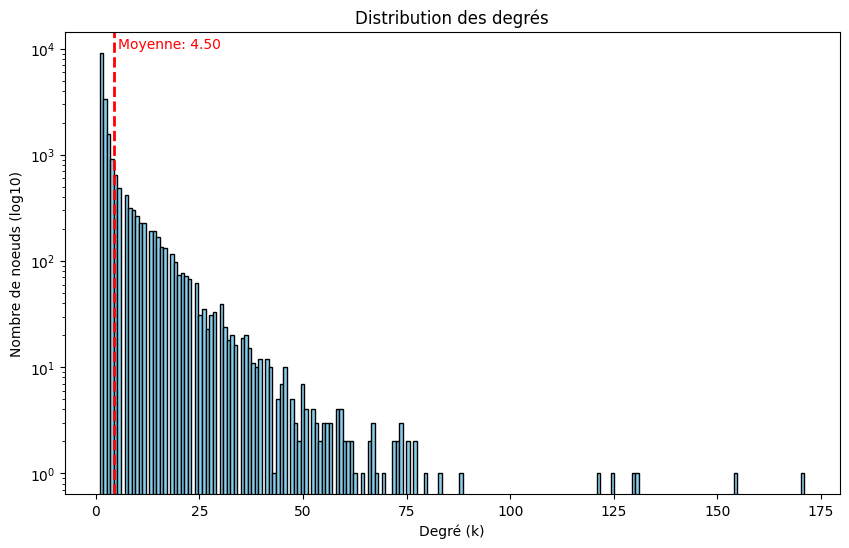

In [5]:
# Degrés
degrees = [d for n, d in G.degree()]
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=200, color='skyblue', edgecolor='black')
plt.axvline(np.mean(degrees), color='red', linestyle='dashed', linewidth=2)
# Afficher la valeur de la moyenne sur le graphe à côté de la ligne rouge en la mettant plutôt en haut de l'image
plt.text(np.mean(degrees) + 1, 10000, f'Moyenne: {np.mean(degrees):.2f}', color='red')

plt.title("Distribution des degrés")
plt.xlabel("Degré (k)")
plt.ylabel("Nombre de noeuds (log10)")
plt.yscale('log')

plt.show()

Analyse de l'histogramme:

- La distribution suit une suit une loi de décroissance exponentiellea attendue. La moyenne est de 4.50. Cela indique qu'en moyenne chaque publication a été citéz un peu moins 5 fois au sein du réseau.
- On peut observer des outliers qui représentent des hubs qui ont des degrés très importants. Ils peuvent représenter des papiers fortement citées et donc références fondamentales dans leur domaine d'étude.

In [6]:
# ===== Test de l'hypothèse de l'homophilie sur les labels ========

# Test d'une homophilie générale
def edge_homophily(G, labels):
    same = 0
    for u, v in G.edges():
        if labels[u] == labels[v]:
            same += 1
    return same / G.number_of_edges()

labels = nx.get_node_attributes(G, "y")
h_obs = edge_homophily(G, labels)
print(f"Homophilie observée : {h_obs:.3f}")

# Comparaison avec le hasard
def random_homophily(G, labels, n_perm=100):
    nodes = list(labels.keys())
    y = np.array([labels[n] for n in nodes])
    h_rand = []

    for _ in range(n_perm):
        y_perm = np.random.permutation(y)
        perm_labels = dict(zip(nodes, y_perm))
        h_rand.append(edge_homophily(G, perm_labels))

    return np.mean(h_rand), np.std(h_rand)

h_rand_mean, h_rand_std = random_homophily(G, labels)
z_score = (h_obs - h_rand_mean) / h_rand_std
print(f"Homophilie aléatoire : {h_rand_mean:.3f} ± {h_rand_std:.3f}")
print(f"Z-score : {z_score:.2f}")

# Homophilie normalisée
def normalized_homophily(h, labels):
    counts = Counter(labels.values())
    n = sum(counts.values())
    p = np.array([c/n for c in counts.values()])
    h_rand = np.sum(p**2)
    h_norm = (h - h_rand) / (1 - h_rand)
    return h_norm, h_rand

h_norm, h_rand_theory = normalized_homophily(h_obs, labels)
print(f"h_rand (théorique) : {h_rand_theory:.3f}")
print(f"Homophilie normalisée : {h_norm:.3f}")

# Homophilie par classe
def class_homophily(G, labels):
    class_edges = {}
    class_same = {}

    for u, v in G.edges():
        cu, cv = labels[u], labels[v]

        for c in (cu, cv):
            class_edges.setdefault(c, 0)
            class_same.setdefault(c, 0)

        class_edges[cu] += 1
        class_edges[cv] += 1

        if cu == cv:
            class_same[cu] += 2

    return {c: class_same[c] / class_edges[c] for c in class_edges}

h_per_class = class_homophily(G, labels)
for c, h in sorted(h_per_class.items()):
    print(f"Classe {c}: homophilie = {h:.3f}")

Homophilie observée : 0.802
Homophilie aléatoire : 0.357 ± 0.003
Z-score : 176.62
h_rand (théorique) : 0.357
Homophilie normalisée : 0.693
Classe 0: homophilie = 0.659
Classe 1: homophilie = 0.853
Classe 2: homophilie = 0.817


 # Analyse des centralités

In [7]:
print("--- Analyse des Centralités ---")

# 1. Degree Centrality (Le plus d'amis)
degree_cent = nx.degree_centrality(G)
# On trie pour avoir le Top 5
top_degree = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 - Degré de centralité (Hubs):")
for node, val in top_degree[:5]:
    print(f"Noeud {node}: {val:.4f}")

# 2. PageRank (Influence)
pagerank_cent = nx.pagerank(G, alpha=0.85)
top_pr = sorted(pagerank_cent.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 - PageRank (Influence):")
for node, val in top_pr[:5]:
    print(f"Node {node}: {val:.4f}")

# 3. Betweenness Centrality
print("\nCalcul de la Betweenness")
between_cent = nx.betweenness_centrality(G, k=800)
top_between = sorted(between_cent.items(), key=lambda x: x[1], reverse=True)

print("Top 5 - Betweenness Centrality (Ponts):")
for node, val in top_between[:5]:
    print(f"Node {node}: {val:.4f}")



--- Analyse des Centralités ---

Top 5 - Degré de centralité (Hubs):
Noeud 11450: 0.0087
Noeud 11024: 0.0078
Noeud 11894: 0.0066
Noeud 12019: 0.0066
Noeud 1205: 0.0063

Top 5 - PageRank (Influence):
Node 11450: 0.0016
Node 11024: 0.0015
Node 12019: 0.0015
Node 1920: 0.0013
Node 2361: 0.0012

Calcul de la Betweenness
Top 5 - Betweenness Centrality (Ponts):
Node 11024: 0.1395
Node 11450: 0.1116
Node 11894: 0.0553
Node 5324: 0.0296
Node 15325: 0.0258


Les centralités permettent de comprendre quels noeuds sont des références dans ce réseau de publications.

### Modèle de Diffusion & Maximisation d'Influence
Simulation du modèle Independent Cascade.


In [8]:
import random
import networkx as nx

def independent_cascade(graph, seed_nodes, proba=0.1):
    """
    Simule le modèle Independent Cascade (IC) vu en cours.
    Une fois activé, un nœud a une chance unique (proba) d'activer ses voisins.
    """
    active_nodes = set(seed_nodes)
    newly_active = set(seed_nodes)
    
    steps = 0
    while newly_active:
        activated_this_step = set()
        for node in newly_active:
            # Pour un papier, on regarde qui le cite (ses voisins)
            neighbors = graph.neighbors(node) if not graph.is_directed() else graph.successors(node)
            for neighbor in neighbors:
                if neighbor not in active_nodes:
                    if random.random() < proba: # Probabilité de transmission
                        activated_this_step.add(neighbor)
        
        active_nodes.update(activated_this_step)
        newly_active = activated_this_step
        steps += 1
        
    return active_nodes, steps

# Calcul local du PageRank pour extraire les "Graines d'influence"
try:
    if 'pagerank_scores' not in locals():
        pagerank_scores = nx.pagerank(G)
    top_pr = sorted(pagerank_scores.items(), key=lambda item: item[1], reverse=True)
    seed_nodes = [node for node, val in top_pr[:5]]
    influenced_nodes, iterations = independent_cascade(G, seed_nodes, proba=0.05)

    print(f"En partant de nos 5 Top-PageRank, l'information a atteint {len(influenced_nodes)} nœuds en {iterations} étapes de diffusion.")
except Exception as e:
    print("Erreur Cascade:", e)



En partant de nos 5 Top-PageRank, l'information a atteint 117 nœuds en 13 étapes de diffusion.


# Détection des communautés


### Algorithme de Louvain (Modularity)
Le cours met un fort accent sur l'approche de la modularité pour trouver des clusters denses.


In [9]:
import community.community_louvain as community_louvain
import networkx as nx

print("--- Détection de communautés : Algorithme de Louvain ---")

# Louvain nécessite un graphe non-orienté
G_undirected = G.to_undirected()

# Calcul de la meilleure partition (maximisation de la modularité)
partition = community_louvain.best_partition(G_undirected)

# Calcul du score de modularité Q (mesurant la qualité de la séparation)
modularity_score = community_louvain.modularity(partition, G_undirected)

# Comptage du nombre de communautés trouvées
num_communities = len(set(partition.values()))

print(f"Nombre de communautés détectées : {num_communities}")
print(f"Score de modularité : {modularity_score:.4f}")
# Un score > 0.3 indique généralement une forte structure communautaire



--- Détection de communautés : Algorithme de Louvain ---
Nombre de communautés détectées : 38
Score de modularité : 0.7709


## Identification des cores


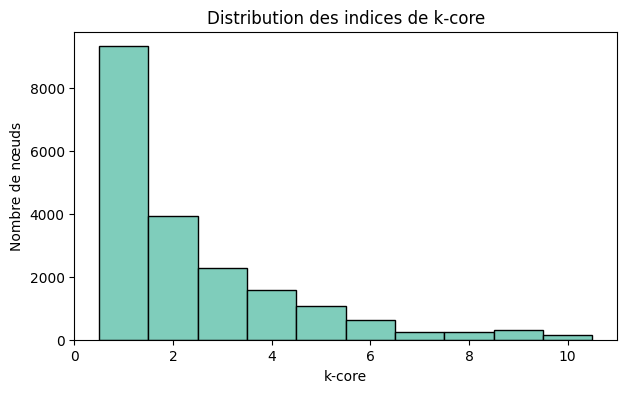

k_max = 10, taille du k-core maximal: 137 nœuds, 1104 arêtes


In [10]:
# Distribution des core index de chaque nœud
core_number = nx.core_number(G)
vals = list(core_number.values())
plt.figure(figsize=(7,4))
plt.hist(vals, bins=range(min(vals), max(vals)+2), color='#7fcdbb', edgecolor='black', align='left')
plt.title("Distribution des indices de k-core")
plt.xlabel("k-core"); plt.ylabel("Nombre de nœuds")
plt.show()

# Extraire le k-core maximal (coeur du réseau)
k_max = max(vals)
G_core = nx.k_core(G, k=k_max)
print(f"k_max = {k_max}, taille du k-core maximal: {G_core.number_of_nodes()} nœuds, {G_core.number_of_edges()} arêtes")


In [11]:
# Densité interne du k-core maximal
density_core = nx.density(G_core)
print(f"Densité interne du k-core: {density_core:.4f}")

# Degré interne moyen (au sein du k-core)
deg_core = [d for _, d in G_core.degree()]
avg_deg_core = np.mean(deg_core)
print(f"Degré interne moyen dans le k-core: {avg_deg_core:.1f}")

# Clustering (cohésion triadique) dans le k-core
avg_clust_core = nx.average_clustering(G_core)
transitivity_core = nx.transitivity(G_core)
print(f"Clustering moyen (k-core): {avg_clust_core:.3f} | Transitivité: {transitivity_core:.3f}")

# Conductance du k-core
core_nodes = set(G_core.nodes())
cond_core = nx.conductance(G, core_nodes)
print(f"Conductance du k-core max (cœur vs reste): {cond_core:.3f}")


Densité interne du k-core: 0.1185
Degré interne moyen dans le k-core: 16.1
Clustering moyen (k-core): 0.230 | Transitivité: 0.208
Conductance du k-core max (cœur vs reste): 0.517


# Tâche de node classification

In [12]:
# Nombre de nœuds dans chaque split
num_train = int(data.train_mask.sum())
num_val = int(data.val_mask.sum())
num_test = int(data.test_mask.sum())


print(f"Nœuds d'entraînement : {num_train}")
print(f"Nœuds de validation : {num_val}")
print(f"Nœuds de test : {num_test}")

Nœuds d'entraînement : 9000
Nœuds de validation : 5000
Nœuds de test : 5717


## Comparaison : Shallow Embeddings (Node2Vec)
En baseline, nous implémentons un Shallow Embedding qui se concentre purement sur la topologie structurelle (Random Walks).


In [39]:
try:
    from torch_geometric.nn import Node2Vec
    import torch_cluster  # Check for dependency


    if 'device' not in globals():
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


    print("--- Entraînement Shallow Embedding : Node2Vec ---")
    # On configure Node2Vec selon les paramètres classiques
    n2v_model = Node2Vec(
        data.edge_index, 
        embedding_dim=64, 
        walk_length=20, 
        context_size=10, 
        walks_per_node=10,
        num_negative_samples=1, 
        p=1.0, q=1.0, 
        sparse=True
    ).to(device)


    loader = n2v_model.loader(batch_size=128, shuffle=True, num_workers=0)
    optimizer_n2v = torch.optim.SparseAdam(list(n2v_model.parameters()), lr=0.01)


    n2v_model.train()
    for epoch in range(1, 11): # Entraînement sur 10 epochs pour l'exemple
        total_loss = 0
        for pos_rw, neg_rw in loader:
            optimizer_n2v.zero_grad()
            loss = n2v_model.loss(pos_rw.to(device), neg_rw.to(device))
            loss.backward()
            optimizer_n2v.step()
            total_loss += loss.item()
        if epoch % 5 == 0:
            print(f'Epoch: {epoch:02d}, Loss: {total_loss / len(loader):.4f}')


except (ImportError, OSError):
    print("⚠️ Node2Vec n'a pas pu être exécuté : 'torch-cluster' n'est pas installé ou incompatible.")
    print("   Cause probable (Windows) : version de torch-cluster incompatible avec la version de PyTorch.")
    print("   Pour réinstaller la version compatible, voir :")
    print("   https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html")
    print("   Cette étape est optionnelle (baseline) et n'empêche pas la suite du notebook.")


⚠️ Node2Vec n'a pas pu être exécuté : 'torch-cluster' n'est pas installé ou incompatible.
   Cause probable (Windows) : version de torch-cluster incompatible avec la version de PyTorch.
   Pour réinstaller la version compatible, voir :
   https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html
   Cette étape est optionnelle (baseline) et n'empêche pas la suite du notebook.


## Méthodes GCN


Paramètres communs pour toutes les méthodes


In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

num_epochs = 200

### GCN - classique

#### Implémentation du réseau

In [16]:
""" Notes :
  - Couche GCNconv (https://pytorch-geometric.readthedocs.io/en/2.4.0/generated/torch_geometric.nn.conv.GCNConv.html)
    - Agrégation normalisée symétriquement
    - Ajout automatique de self-loops (matrice d'adjacence aditionnée avec matrice identitié (self-loops))

  - Conséquences connues :
    - très bon biais inductif
    - diffusion rapide
    - over-smoothing quand K augmente
"""
class GCN_Dynamic(torch.nn.Module):
    def __init__(self, num_features, num_classes, num_layers, hidden_dim=16):
        super().__init__()
        self.layers = torch.nn.ModuleList()

        # Première couche (Input -> Hidden)
        self.layers.append(GCNConv(num_features, hidden_dim))

        # Couches intermédiaires (Hidden -> Hidden)
        # On ajoute (K - 2) couches cachées
        for _ in range(num_layers - 2):
            self.layers.append(GCNConv(hidden_dim, hidden_dim))

        # Dernière couche (Hidden -> Output/Classes)
        # Si K=1, on fait directement Input -> Output
        if num_layers == 1:
            self.layers = torch.nn.ModuleList([GCNConv(num_features, num_classes)])
        else:
            self.layers.append(GCNConv(hidden_dim, num_classes))

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Passage à travers toutes les couches sauf la dernière
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)

        # Dernière couche (pas de ReLU ni Dropout juste avant le Softmax)
        x = self.layers[-1](x, edge_index)

        return F.log_softmax(x, dim=1)

#### Test de la méthode

--- Démarrage du Benchmark sur cpu ---

Test avec K = 1 couches...
 -> Précision finale (K=1) : 0.7689


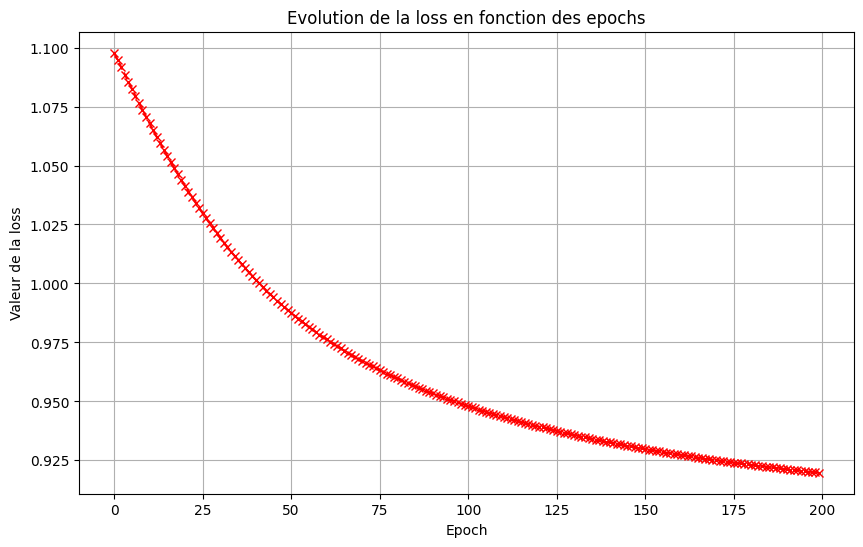


Test avec K = 2 couches...
 -> Précision finale (K=2) : 0.8457


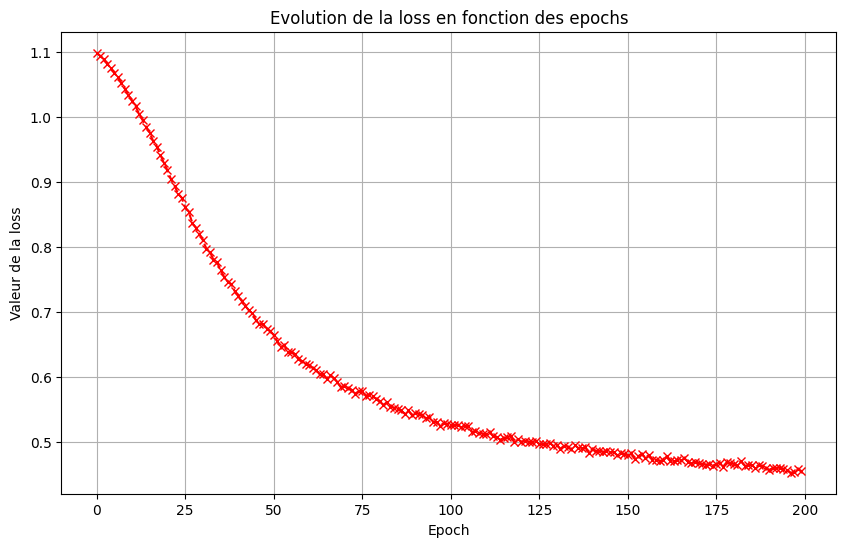


Test avec K = 3 couches...
 -> Précision finale (K=3) : 0.8518


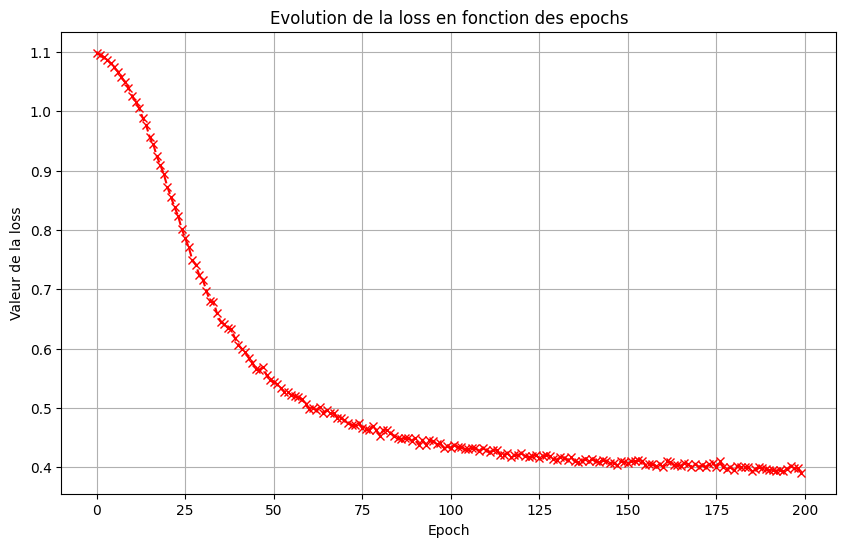


Test avec K = 4 couches...
 -> Précision finale (K=4) : 0.8585


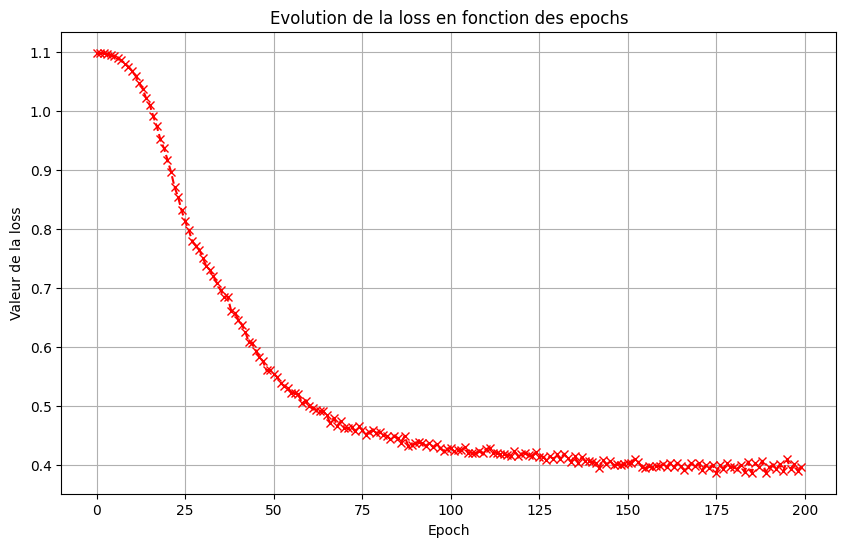


Test avec K = 5 couches...
 -> Précision finale (K=5) : 0.8412


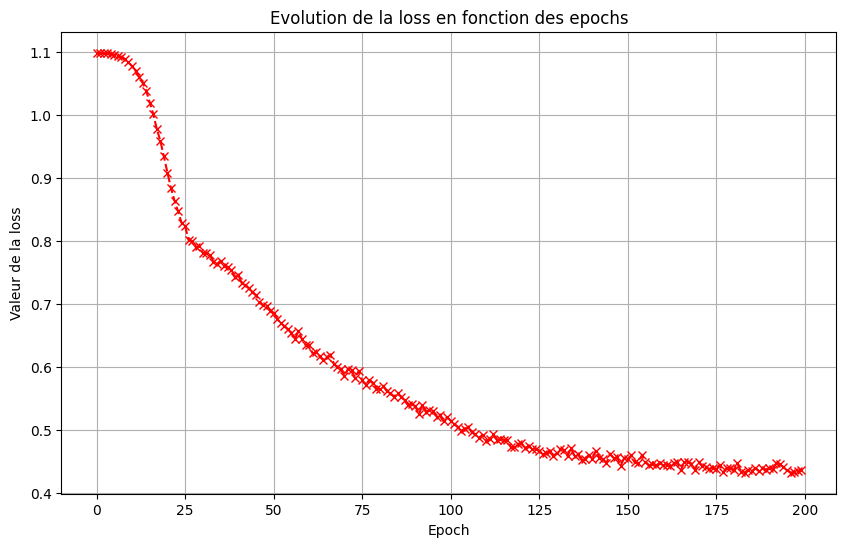


Test avec K = 6 couches...
 -> Précision finale (K=6) : 0.8324


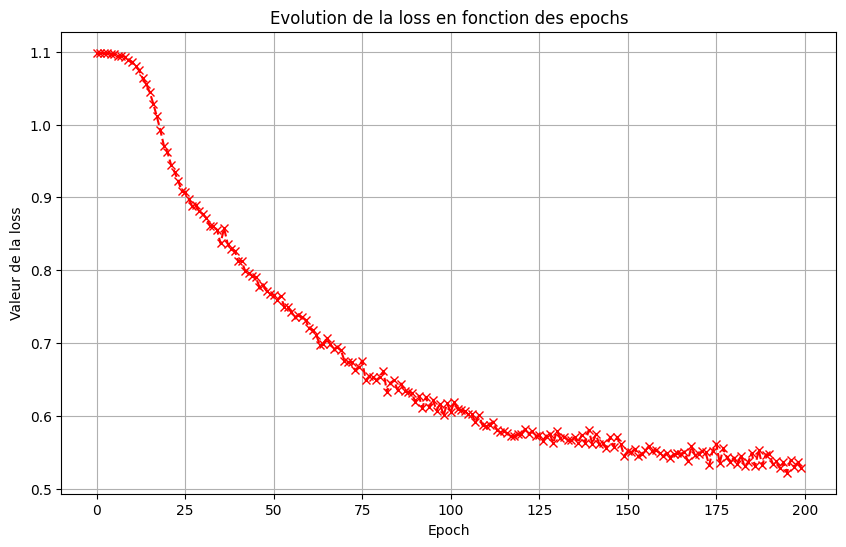

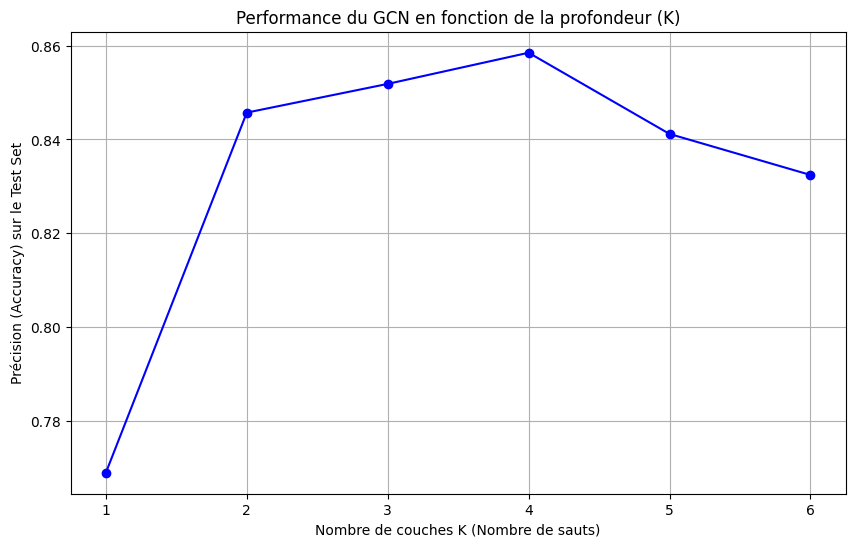

In [23]:
k_values = [1, 2, 3, 4, 5, 6]
accuracies = []

loss_history = {}

print(f"--- Démarrage du Benchmark sur {device} ---")

for k in k_values:
    print(f"\nTest avec K = {k} couches...")
    model = GCN_Dynamic(dataset.num_features, dataset.num_classes, num_layers=k).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    # Liste pour stocker la loss à chaque epoch
    epoch_losses = []

    # Entraînement
    model.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask]) # negative log-likelihood
        loss.backward()
        optimizer.step()

         # Sauvegarde de la loss
        epoch_losses.append(loss.item())

    # Évaluation
    model.eval()
    pred = model(data).argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
    acc = int(correct) / int(data.test_mask.sum())
    accuracies.append(acc)
    print(f" -> Précision finale (K={k}) : {acc:.4f}")

    # Affichage losses pour ce K
    loss_history[k] = epoch_losses
    plt.figure(figsize=(10, 6))
    plt.plot(list(range(num_epochs)), epoch_losses, marker='x', linestyle='--', color='r')
    plt.title("Evolution de la loss en fonction des epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Valeur de la loss")
    plt.grid()
    plt.show()

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title("Performance du GCN en fonction de la profondeur (K)")
plt.xlabel("Nombre de couches K (Nombre de sauts)")
plt.ylabel("Précision (Accuracy) sur le Test Set")
plt.grid(True)
plt.xticks(k_values)
plt.show()

On observe que pour K>3, l'accuracy diminue et la loss augmente. Cela est dû à un over-smoothing qui est prévu par la théorie.

## GCN - SAGE

#### Implementation du réseau

In [24]:
""" Notes :
  - Couche SAGEConv (https://pytorch-geometric.readthedocs.io/en/2.7.0/generated/torch_geometric.nn.conv.SAGEConv.html)

"""

class GraphSAGE_Dynamic(torch.nn.Module):
    def __init__(self, num_features, num_classes, num_layers, hidden_dim=16):
        super().__init__()
        self.layers = torch.nn.ModuleList()

        # Première couche
        self.layers.append(SAGEConv(num_features, hidden_dim, aggr="mean"))

        # Couches intermédiaires
        for _ in range(num_layers - 2):
            self.layers.append(SAGEConv(hidden_dim, hidden_dim, aggr="mean"))

        # Dernière couche
        if num_layers == 1:
            self.layers = torch.nn.ModuleList(
                [SAGEConv(num_features, num_classes, aggr="mean")]
            )
        else:
            self.layers.append(SAGEConv(hidden_dim, num_classes, aggr="mean"))

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        for layer in self.layers[:-1]:
            x = layer(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)

        x = self.layers[-1](x, edge_index)
        return F.log_softmax(x, dim=1)


#### Test de la méthode

In [25]:
sage_accuracies = []
sage_loss_history = {}

print(f"\n--- Benchmark GraphSAGE sur {device} ---")

for k in k_values:
    print(f"\nTest GraphSAGE avec K = {k} couches...")

    model = GraphSAGE_Dynamic(
        dataset.num_features,
        dataset.num_classes,
        num_layers=k
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01,
        weight_decay=5e-4
    )

    epoch_losses = []

    model.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    sage_loss_history[k] = epoch_losses

    model.eval()
    pred = model(data).argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
    acc = int(correct) / int(data.test_mask.sum())
    sage_accuracies.append(acc)

    print(f" -> Accuracy GraphSAGE (K={k}) : {acc:.4f}")


--- Benchmark GraphSAGE sur cpu ---

Test GraphSAGE avec K = 1 couches...
 -> Accuracy GraphSAGE (K=1) : 0.7885

Test GraphSAGE avec K = 2 couches...
 -> Accuracy GraphSAGE (K=2) : 0.8667

Test GraphSAGE avec K = 3 couches...
 -> Accuracy GraphSAGE (K=3) : 0.8653

Test GraphSAGE avec K = 4 couches...
 -> Accuracy GraphSAGE (K=4) : 0.8618

Test GraphSAGE avec K = 5 couches...
 -> Accuracy GraphSAGE (K=5) : 0.8503

Test GraphSAGE avec K = 6 couches...
 -> Accuracy GraphSAGE (K=6) : 0.8415


### Comparaison des deux variantes GCN

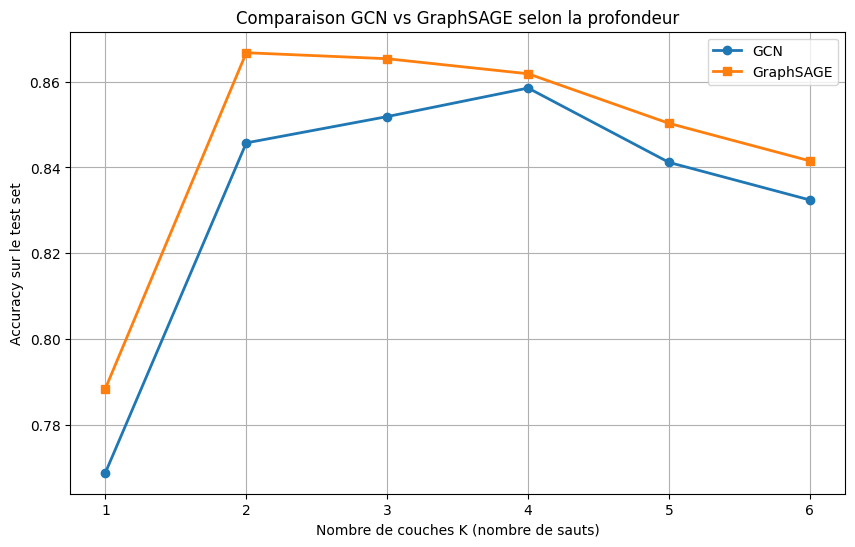

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(k_values, accuracies, marker='o', label="GCN", linewidth=2)
plt.plot(k_values, sage_accuracies, marker='s', label="GraphSAGE", linewidth=2)

plt.xlabel("Nombre de couches K (nombre de sauts)")
plt.ylabel("Accuracy sur le test set")
plt.title("Comparaison GCN vs GraphSAGE selon la profondeur")
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()


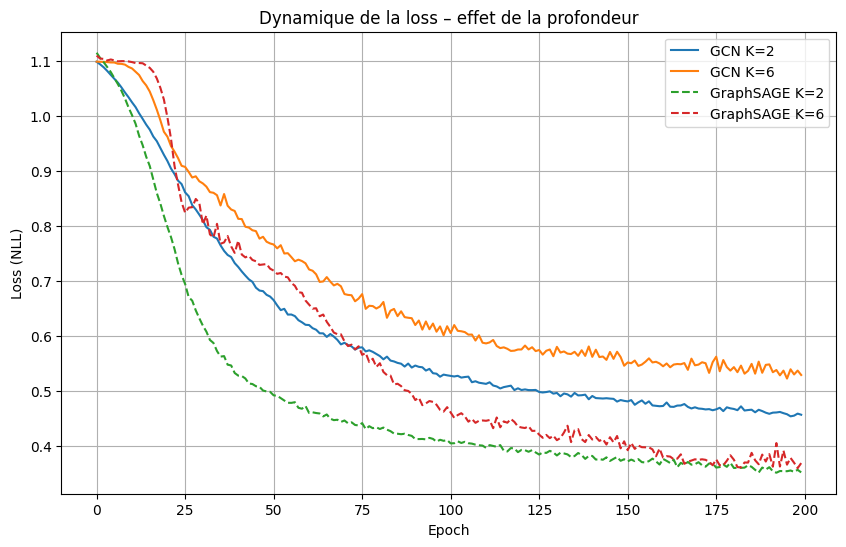

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(loss_history[2], label="GCN K=2")
plt.plot(loss_history[6], label="GCN K=6")

plt.plot(sage_loss_history[2], linestyle='--', label="GraphSAGE K=2")
plt.plot(sage_loss_history[6], linestyle='--', label="GraphSAGE K=6")

plt.xlabel("Epoch")
plt.ylabel("Loss (NLL)")
plt.title("Dynamique de la loss – effet de la profondeur")
plt.legend()
plt.grid(True)
plt.show()



## Link prediction

### Création des encodeurs

Le GNN sert uniquement à apprendre des embeddings de nœuds.

In [35]:
class GCN_Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Première couche : agrégation + non-linéarité
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        # Deuxième couche : embeddings finaux
        x = self.conv2(x, edge_index)
        return x


In [36]:
class GraphSAGE_Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr="mean")
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr="mean")

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        x = self.conv2(x, edge_index)
        return x


### Split du graphe (positif et négatif)

Le split est réalisé sur les arêtes uniquement. Tous les nœuds restent observés (cadre transductif).

In [28]:
from torch_geometric.transforms import RandomLinkSplit


# Split rigoureux (slides Part II - 22) avec échantillons négatifs équilibrés
splitter = RandomLinkSplit(
    is_undirected=True,
    num_val=0.1,        # 10% validation
    num_test=0.1,       # 10% test
    add_negative_train_samples=True
 )


train_data, val_data, test_data = splitter(data.cpu())


# Envoi sur le bon device
train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)


def count_pos_neg(edge_labels):
    pos = int((edge_labels == 1).sum())
    neg = int((edge_labels == 0).sum())
    return pos, neg


train_pos, train_neg = count_pos_neg(train_data.edge_label)
val_pos, val_neg = count_pos_neg(val_data.edge_label)
test_pos, test_neg = count_pos_neg(test_data.edge_label)


print("Split RandomLinkSplit appliqué (transductif, classes équilibrées)")
print(f"Train edges: {train_data.edge_label_index.shape[1]} (pos={train_pos}, neg={train_neg})")
print(f"Val   edges: {val_data.edge_label_index.shape[1]} (pos={val_pos}, neg={val_neg})")
print(f"Test  edges: {test_data.edge_label_index.shape[1]} (pos={test_pos}, neg={test_neg})")



Split RandomLinkSplit appliqué (transductif, classes équilibrées)
Train edges: 70920 (pos=35460, neg=35460)
Val   edges: 8864 (pos=4432, neg=4432)
Test  edges: 8864 (pos=4432, neg=4432)


### Décodeur

In [29]:
def decode_dot_product(z, edge_index):
    """
    Calcule un score de lien pour chaque paire (u, v)
    via le produit scalaire des embeddings.
    """
    src, dst = edge_index
    return (z[src] * z[dst]).sum(dim=1)


### Loss

In [30]:
def link_prediction_loss(z, edge_label_index, edge_label):
    """
    BCE avec logits pour scorer les arêtes positives (1) et négatives (0)
    générées par RandomLinkSplit (classes équilibrées).
    """
    logits = decode_dot_product(z, edge_label_index)
    return F.binary_cross_entropy_with_logits(logits, edge_label.float())



### Entrainement de l'encodeur

In [31]:
def train_link_predictor(model, data, num_epochs=200):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []


    for epoch in range(num_epochs):
        optimizer.zero_grad()


        # Embeddings de tous les nœuds
        z = model(data.x, data.edge_index)


        # BCE binaire sur les arêtes positives/négatives déjà équilibrées
        loss = link_prediction_loss(
            z,
            data.edge_label_index,
            data.edge_label
)


        loss.backward()
        optimizer.step()


        losses.append(loss.item())


    return losses



### Evaluation

In [32]:
@torch.no_grad()
def evaluate_link_predictor(model, data):
    model.eval()


    z = model(data.x, data.edge_index)
    logits = decode_dot_product(z, data.edge_label_index)
    probs = torch.sigmoid(logits).cpu()
    labels = data.edge_label.cpu()


    auc = roc_auc_score(labels, probs)
    ap = average_precision_score(labels, probs)


    return auc, ap



### Benchmark

### Graph Attention Network (GAT)


GCN et GraphSAGE traitent tous les voisins équitablement. Le **GAT** (Veličković et al., 2018 – cours *GraphEmbeddingsPartII*) apprend un **score d’attention** pour chaque arête afin de pondérer l’influence de chaque voisin.
L’attention est calculée comme :

$$\alpha_{ij} = \frac{\exp(\text{LeakyReLU}(a^T [W h_i \| W h_j]))}{\sum_{k \in \mathcal{N}(i)} \exp(\text{LeakyReLU}(a^T [W h_i \| W h_k]))}$$


En utilisant **plusieurs têtes d’attention** (*multi-head attention*), le modèle stabilise l’apprentissage et capture plusieurs types de dépendances simultanément.

In [33]:
from torch_geometric.nn import GATConv


class GAT_Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super(GAT_Encoder, self).__init__()
        # On utilise plusieurs têtes d'attention (heads) pour stabiliser l'apprentissage
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        # La sortie concatène ou moyenne les têtes
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.6)


    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.6, training=self.training)
        return self.conv2(x, edge_index)


gat_model = GAT_Encoder(
    in_channels=dataset.num_features,
    hidden_channels=64,
    out_channels=64
).to(device)


print("Modèle GAT instancié (Multi-head Attention) !")



Modèle GAT instancié (Multi-head Attention) !



--- Entraînement GCN ---
  Val  → AUC:0.9507  AP:0.9542
  Test → AUC:0.9551  AP:0.9564

--- Entraînement GraphSAGE ---
  Val  → AUC:0.8521  AP:0.8596
  Test → AUC:0.8604  AP:0.8617

--- Entraînement GAT ---
  Val  → AUC:0.9373  AP:0.9281
  Test → AUC:0.9415  AP:0.9316


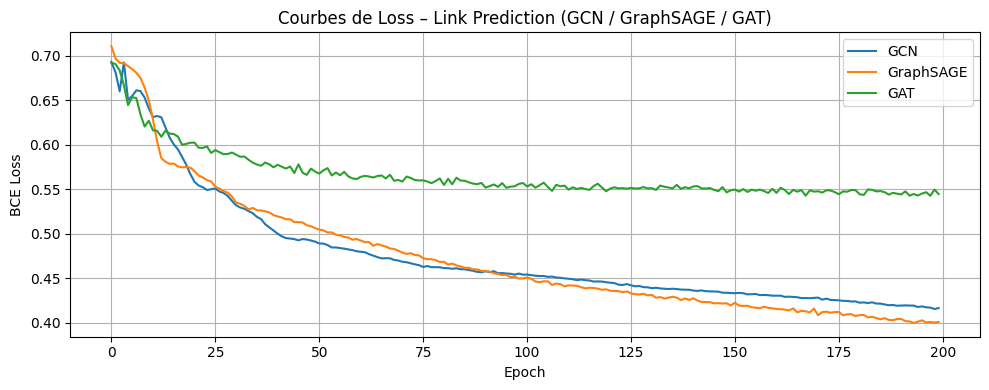

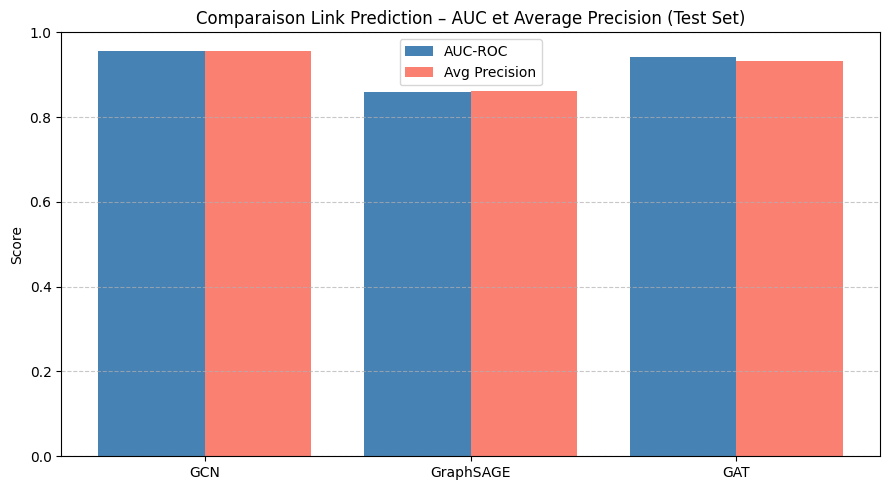

In [37]:
# ============================================================
# Benchmark Link Prediction : GCN vs GraphSAGE vs GAT
# (RandomLinkSplit, BCE, AUC, AP)
# ============================================================


gcn_lp  = GCN_Encoder(dataset.num_features, 64, 64).to(device)
sage_lp = GraphSAGE_Encoder(dataset.num_features, 64, 64).to(device)
gat_lp  = GAT_Encoder(dataset.num_features, 64, 64).to(device)


results = {}


for name, mod in [("GCN", gcn_lp), ("GraphSAGE", sage_lp), ("GAT", gat_lp)]:
    print(f"\n--- Entraînement {name} ---")
    losses = train_link_predictor(mod, train_data, num_epochs=200)
    val_auc, val_ap   = evaluate_link_predictor(mod, val_data)
    test_auc, test_ap = evaluate_link_predictor(mod, test_data)
    results[name] = {"losses": losses, "val_auc": val_auc, "val_ap": val_ap,
                     "test_auc": test_auc, "test_ap": test_ap}
    print(f"  Val  → AUC:{val_auc:.4f}  AP:{val_ap:.4f}")
    print(f"  Test → AUC:{test_auc:.4f}  AP:{test_ap:.4f}")


# --- Courbes de loss ---
plt.figure(figsize=(10, 4))
for name in results:
    plt.plot(results[name]["losses"], label=name)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Courbes de Loss – Link Prediction (GCN / GraphSAGE / GAT)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --- Bar chart AUC / AP (Test set) ---
models_names = list(results.keys())
auc_scores = [results[m]["test_auc"] for m in models_names]
ap_scores  = [results[m]["test_ap"]  for m in models_names]
x = range(len(models_names))


plt.figure(figsize=(9, 5))
plt.bar([i - 0.2 for i in x], auc_scores, width=0.4, label="AUC-ROC", color="steelblue")
plt.bar([i + 0.2 for i in x], ap_scores,  width=0.4, label="Avg Precision", color="salmon")
plt.xticks(x, models_names)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Comparaison Link Prediction – AUC et Average Precision (Test Set)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Bilan du projet

---

### ✅ Ce que nous avons exploré

| Module du cours | Implémentation dans ce notebook |
|---|---|
| *GraphProperties* | Statistiques, distribution des degrés, **homophilie** (h=0.802), Degree / PageRank / Betweenness |
| *lInfluenceMaximisation* | Modèle **Independent Cascade** avec les 5 top-PageRank comme graines (117 nœuds atteints, 13 étapes) |
| *communityDetection* | **Louvain** (38 communautés, Q=0.7709) + **k-core** (k_max=10, 137 nœuds) |
| *graphShallowEmbeddings* | **Node2Vec** comme baseline structurale (sans features) |
| *GNN – Node Classification* | **GCN** et **GraphSAGE** avec analyse de l'over-smoothing (k=1..6) |
| *GNN – Link Prediction* | **GCN / GraphSAGE / GAT** avec `RandomLinkSplit`, BCE loss, AUC-ROC et Average Precision |

---

### 🟠 Choix méthodologiques : ce que nous n'avons volontairement pas fait

#### 1. Node Classification sur PubMed
**Pourquoi c'est intéressant** : PubMed est historiquement conçu pour classifier les articles dans 3 catégories (Diabète type 1, 2, expérimental). C'est la tâche canonique du dataset.  
**Pourquoi on ne l'a pas fait** : Le projet demandait de se concentrer sur la **Link Prediction**. Nous avons volontairement détourné le dataset de sa tâche principale pour évaluer la capacité des GNNs à prédire des citations (arêtes), ce qui est plus représentatif des cas d'usage en biomédical (ex. prédiction d'interactions médicamenteuses).

#### 2. Algorithme glouton pour la Maximisation d'Influence
**Pourquoi c'est intéressant** : Le cours (*lInfluenceMaximisation*) présente un algorithme glouton fondé sur la **sous-modularité** pour trouver mathématiquement les k meilleures graines.  
**Pourquoi on ne l'a pas fait** : Sur PubMed (19 717 nœuds, 44 338 arêtes), cet algorithme a une complexité de O(k · n · R) avec R simulations Monte-Carlo — prohibitif en pratique. Nous utilisons le **PageRank comme heuristique** : les nœuds à fort PageRank sont de facto de bons influenceurs, et cette approximation est standard dans la littérature.

#### 3. DeepWalk et Walktrap
**Pourquoi c'est intéressant** : DeepWalk et Walktrap sont des méthodes classiques basées sur les marches aléatoires, présentées dans les cours.  
**Pourquoi on ne l'a pas fait** : **Node2Vec généralise DeepWalk** (paramètres p=1, q=1 → DeepWalk), il est donc redondant de les implémenter tous les deux. Pour les communautés, **Louvain est plus rapide et plus standard** que Walktrap sur les grands graphes ; il aurait été redondant d'implémenter les deux.

#### 4. Modèles Translationnels (TransE, RotatE, ComplEx)
**Pourquoi c'est intéressant** : Ces modèles sont présentés dans le cours pour la complétion de graphes de connaissances.  
**Pourquoi on ne l'a pas fait** : PubMed est un **graphe homogène** (un seul type de nœud : "Article", un seul type d'arête : "Cite"). Les modèles translationnels sont conçus pour les graphes **hétérogènes / multi-relationnels** avec différents types de relations. Les appliquer sur PubMed n'aurait aucun sens mathématique — ils seront utilisés dans l'Axe 2 sur des Knowledge Graphs.

---

### Discussion : Extension aux Graphes Biomédicaux (Cancer / PPI)

La même méthodologie développée ici sur PubMed s'applique directement aux **réseaux d'interactions protéine–protéine (PPI)** utilisés dans la recherche sur le cancer.

| Étape | PubMed (ce projet) | Cancer / PPI |
|---|---|---|
| Nœuds | Articles scientifiques | Protéines / gènes |
| Arêtes | Citations | Interactions biologiques |
| Features | TF-IDF (500 mots-clés) | Expression génique, séquence |
| Tâche 1 | Link Prediction (citation) | Drug-Target Prediction |
| Tâche 2 | Détection de communautés | Identification de complexes protéiques |

**Points clés de transfert :**
1. **Équilibrage** : `RandomLinkSplit` avec `add_negative_train_samples=True` est indispensable en biomédical où les vrais liens positifs sont rares.
2. **Loss BCE** : `binary_cross_entropy_with_logits` gère correctement le déséquilibre positifs/négatifs.
3. **GAT** : le mécanisme d'attention est particulièrement adapté aux réseaux biologiques car toutes les interactions n'ont pas la même importance fonctionnelle.
4. **Métriques** : AUC-ROC et Average Precision sont les métriques de référence pour les données médicales déséquilibrées.
5. **Baseline Node2Vec** : les shallow embeddings restent une référence à battre avant d'introduire les features dans les GNNs.